In [1]:
# prompt: mount to google drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import torch
from torch import nn
import torch.nn.functional as F
from transformers import AutoModel
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import os
import json
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from cleantext import clean

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# # ------------------ Dataset ------------------
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class CrisisClassifier(nn.Module):
    def __init__(self, input_size, output_size=11, hidden_dim=128, num_heads=4, dim_feedforward=2048,
                 num_layers=4, dropout=0.1, max_len=512,  device=device):
        super().__init__()
        self.embeddingL = nn.Embedding(input_size, hidden_dim)
        self.posembeddingL = nn.Embedding(max_len, hidden_dim)

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers)

        self.informative_linear = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 2)
        )

        self.gating_linear = nn.Sequential(
            nn.Linear(hidden_dim + 2, hidden_dim),
            nn.Sigmoid()
        )

        self.humanitarian_cat_linear = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, output_size)
        )

    def forward(self, x):
        pos_size = x.shape[1]
        pos_one_row = torch.arange(pos_size, device=x.device)
        pos = pos_one_row.expand(x.shape)

        embedding = self.embeddingL(x) + self.posembeddingL(pos)  # (batch_size, seq_len, hidden_dim)
        encoder_output = self.encoder(embedding)                 # (batch_size, seq_len, hidden_dim)
        pooled_output = encoder_output.mean(dim=1)               # (batch_size, hidden_dim)

        logits_informative = self.informative_linear(pooled_output)   # (batch_size, 2)
        probability_informative = F.softmax(logits_informative, dim=1)
        pooled_plus_probs = torch.cat([pooled_output, probability_informative], dim=1)

        logits_gating = self.gating_linear(pooled_plus_probs)     # (batch_size, hidden_dim)
        pooled_gating = pooled_output * logits_gating

        logits_humanitarian = self.humanitarian_cat_linear(pooled_gating)  # (batch_size, output_size)

        return logits_informative, logits_humanitarian

#------------Clean text-----------
def clean_text(self, text):
        return clean(text,
                fix_unicode=True,               # fix various unicode errors
                to_ascii=True,                  # transliterate to closest ASCII representation
                lower=True,                     # lowercase text
                no_line_breaks=False,           # fully strip line breaks as opposed to only normalizing them
                no_urls=False,                  # replace all URLs with a special token
                no_emails=False,                # replace all email addresses with a special token
                no_phone_numbers=False,         # replace all phone numbers with a special token
                no_numbers=False,               # replace all numbers with a special token
                no_digits=False,                # replace all digits with a special token
                no_currency_symbols=False,      # replace all currency symbols with a special token
                no_punct=False,                 # remove punctuations
                replace_with_punct="",          # instead of removing punctuations you may replace them
                replace_with_url="<URL>",
                replace_with_email="<EMAIL>",
                replace_with_phone_number="<PHONE>",
                replace_with_number="<NUMBER>",
                replace_with_digit="0",
                replace_with_currency_symbol="<CUR>",
                lang="en"                       # set to 'de' for German special handling
            )

# ---------- Focal Loss ----------

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean', device=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight.to(device) if weight is not None else None
        self.reduction = reduction

    def forward(self, input, target):
        logpt = F.log_softmax(input, dim=1)                     # log(p_t)
        pt = logpt.exp()                                        # p_t
        target = target.view(-1, 1)
        logpt = logpt.gather(1, target).squeeze(1)             # get log(p_t) for correct class
        pt = pt.gather(1, target).squeeze(1)                   # get p_t for correct class

        if self.weight is not None:
            at = self.weight[target.squeeze()]                # class-specific weight
        else:
            at = torch.ones_like(pt)

        loss = -at * (1 - pt) ** self.gamma * logpt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss





In [15]:

class CrisisDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        self.max_len = max_len

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        encoding = self.tokenizer(
            row['text'],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'crisis_type': int(row["humanitarian_label"]),
            'informativeness': int(row["informativeness_label"]),
        }

def train(model, dataloader, optimizer,
          criterion_info, criterion_crisis, device,
          teacher_logits=None, alpha_train=0.01, alpha_dist=0.8,
          temperature=2.0, current_epoch=0, warmup_epochs=3):

    model.train()
    total_loss = 0
    use_distill = teacher_logits is not None and current_epoch >= warmup_epochs

    progress_bar = tqdm(dataloader, ascii=True)
    for batch_idx, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        crisis_labels = batch['crisis_type'].to(device)
        info_labels = batch['informativeness'].to(device)

        optimizer.zero_grad()

        logits_info, logits_crisis = model(input_ids)

        loss_info = criterion_info(logits_info, info_labels)

        # Only compute crisis loss for informative examples
        is_informative = (info_labels == 1)
        if is_informative.sum() > 0:
            loss_crisis = criterion_crisis(logits_crisis[is_informative], crisis_labels[is_informative])
        else:
            loss_crisis = torch.tensor(0.0, dtype=torch.float, device=device)

        # Base loss: weighted sum of both
        base_loss = alpha_train * loss_info + (1 - alpha_train) * loss_crisis

        if use_distill:
            with torch.no_grad():
                t_info_logits, t_crisis_logits = teacher_logits[batch_idx]

            # KL divergence for informativeness
            distill_info = F.kl_div(
                F.log_softmax(logits_info / temperature, dim=1),
                F.softmax(t_info_logits / temperature, dim=1),
                reduction='batchmean'
            ) * (temperature ** 2)

            # KL divergence for crisis types (only informative samples)
            if is_informative.sum() > 0:
                distill_crisis = F.kl_div(
                    F.log_softmax(logits_crisis[is_informative] / temperature, dim=1),
                    F.softmax(t_crisis_logits[is_informative] / temperature, dim=1),
                    reduction='batchmean'
                ) * (temperature ** 2)
            else:
                distill_crisis = torch.tensor(0.0, device=device)

            distill_loss = distill_info + distill_crisis
            loss = alpha_dist * base_loss + (1 - alpha_dist) * distill_loss
        else:
            # Only base loss during warmup
            loss = base_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_description_str(
            f"Epoch {current_epoch} | Batch {batch_idx} | Total: {loss.item():.4f} | Info: {loss_info.item():.4f} | Crisis: {loss_crisis.item():.4f}"
        )


# ------------------ Evaluation Function ------------------
def eval_model(model, dataloader, device, informative_idx=1, not_humanitarian_idx=0):
    model.eval()
    all_info_preds, all_info_labels = [], []
    all_crisis_preds, all_crisis_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            info_true = batch["informativeness"].to(device)
            crisis_true = batch["crisis_type"].to(device)

            informativeness_logits, crisis_logits = model(input_ids)

            info_preds = torch.argmax(informativeness_logits, dim=1).cpu().numpy()
            crisis_preds = torch.argmax(crisis_logits, dim=1).cpu().numpy()

            crisis_preds[info_preds != informative_idx] = not_humanitarian_idx

            all_info_preds.extend(info_preds)
            all_info_labels.extend(info_true.cpu().numpy())
            all_crisis_preds.extend(crisis_preds)
            all_crisis_labels.extend(crisis_true.cpu().numpy())

    return (
        np.array(all_info_labels),
        np.array(all_info_preds),
        np.array(all_crisis_labels),
        np.array(all_crisis_preds),
    )
# ------------------ Plot Confusion Matrix ------------------
def plot_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300)
    plt.show()


In [16]:

# ------------------ Load Data ------------------
train_df = pd.read_csv("/content/drive/MyDrive/group_project/combined_train.tsv", sep="\t").dropna().reset_index(drop=True)
val_df = pd.read_csv("/content/drive/MyDrive/group_project/combined_test.tsv", sep="\t").dropna().reset_index(drop=True)

info_labels = ['not_informative', 'informative']
info2id = {label: idx for idx, label in enumerate(info_labels)}
id2info = {idx: label for label, idx in info2id.items()}
hum_labels = sorted(train_df["humanitarian_label"].unique())
hum2id = {label: idx for idx, label in enumerate(hum_labels)}
id2hum = {idx: label for label, idx in hum2id.items()}

train_df["informativeness_label"] = train_df["informativeness_label"].map(info2id)
val_df["informativeness_label"] = val_df["informativeness_label"].map(info2id)
train_df["humanitarian_label"] = train_df["humanitarian_label"].map(hum2id)
val_df["humanitarian_label"] = val_df["humanitarian_label"].map(hum2id)

data_train = CrisisDataset(train_df, tokenizer, max_len=128)
data_val = CrisisDataset(val_df, tokenizer, max_len=128)

train_loader = DataLoader(data_train, batch_size=32, shuffle=True)
val_loader = DataLoader(data_val, batch_size=32)


humanitarian_class_counts = Counter(train_df['humanitarian_label'])
total = sum(humanitarian_class_counts.values())
humanitarian_class_weights = torch.tensor([
    1.0 - (humanitarian_class_counts[i] / total)
    for i in range(len(train_df['humanitarian_label'].unique()))
], dtype=torch.float)



🛠️ Training Teacher Model...


Epoch 0 | Batch 546 | Total: 1.0778 | Info: 0.6432 | Crisis: 1.0822:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 1 | Batch 546 | Total: 1.0534 | Info: 0.6947 | Crisis: 1.0571:   0%|          | 0/547 [00:17<?, ?it/s]
Epoch 2 | Batch 546 | Total: 0.9497 | Info: 0.6545 | Crisis: 0.9527:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 3 | Batch 546 | Total: 1.2699 | Info: 0.5209 | Crisis: 1.2775:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 4 | Batch 546 | Total: 1.0144 | Info: 0.5185 | Crisis: 1.0194:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 5 | Batch 546 | Total: 0.7681 | Info: 0.5464 | Crisis: 0.7704:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 6 | Batch 546 | Total: 1.1808 | Info: 0.4115 | Crisis: 1.1886:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 7 | Batch 546 | Total: 1.1159 | Info: 0.5409 | Crisis: 1.1217:   0%|          | 0/547 [00:17<?, ?it/s]
Epoch 8 | Batch 546 | Total: 0.5689 | Info: 0.4027 | Crisis: 0.5705:   0%|          | 0/547 [00:17<?, ?it/s]
Epoch 9 | Batch 546


📜 Classification Report (Teacher)
                 precision    recall  f1-score   support

not_informative       0.82      0.78      0.80      5634
    informative       0.74      0.78      0.76      4355

       accuracy                           0.78      9989
      macro avg       0.78      0.78      0.78      9989
   weighted avg       0.78      0.78      0.78      9989

                                     precision    recall  f1-score   support

                affected_individual       0.07      0.78      0.13       601
                 caution_and_advice       0.18      0.27      0.21       476
          displaced_and_evacuations       0.00      0.00      0.00        43
          donation_and_volunteering       0.55      0.62      0.58       505
infrastructure_and_utilities_damage       0.09      0.01      0.01       421
             injured_or_dead_people       0.39      0.18      0.24       261
           missing_and_found_people       0.00      0.00      0.00        31
   

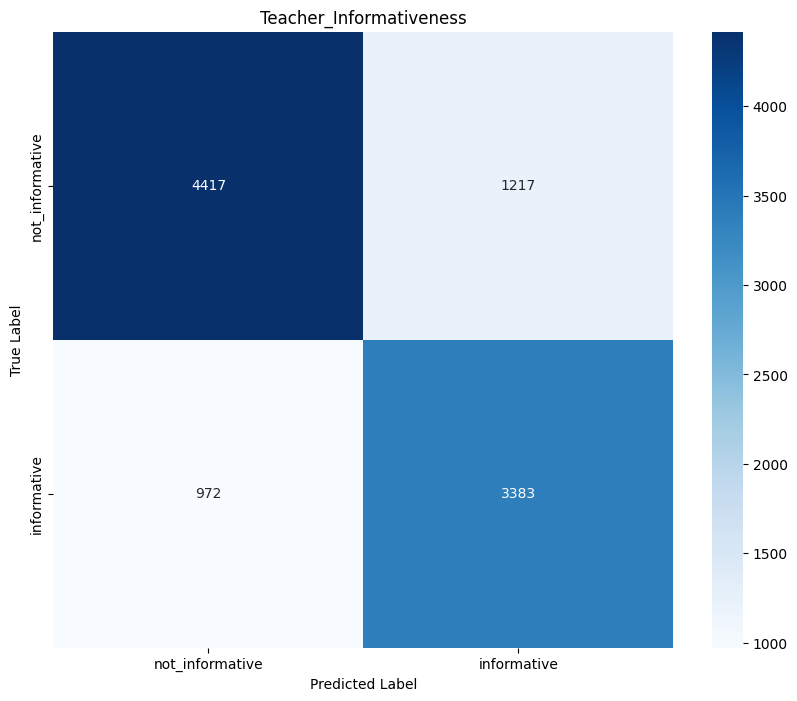

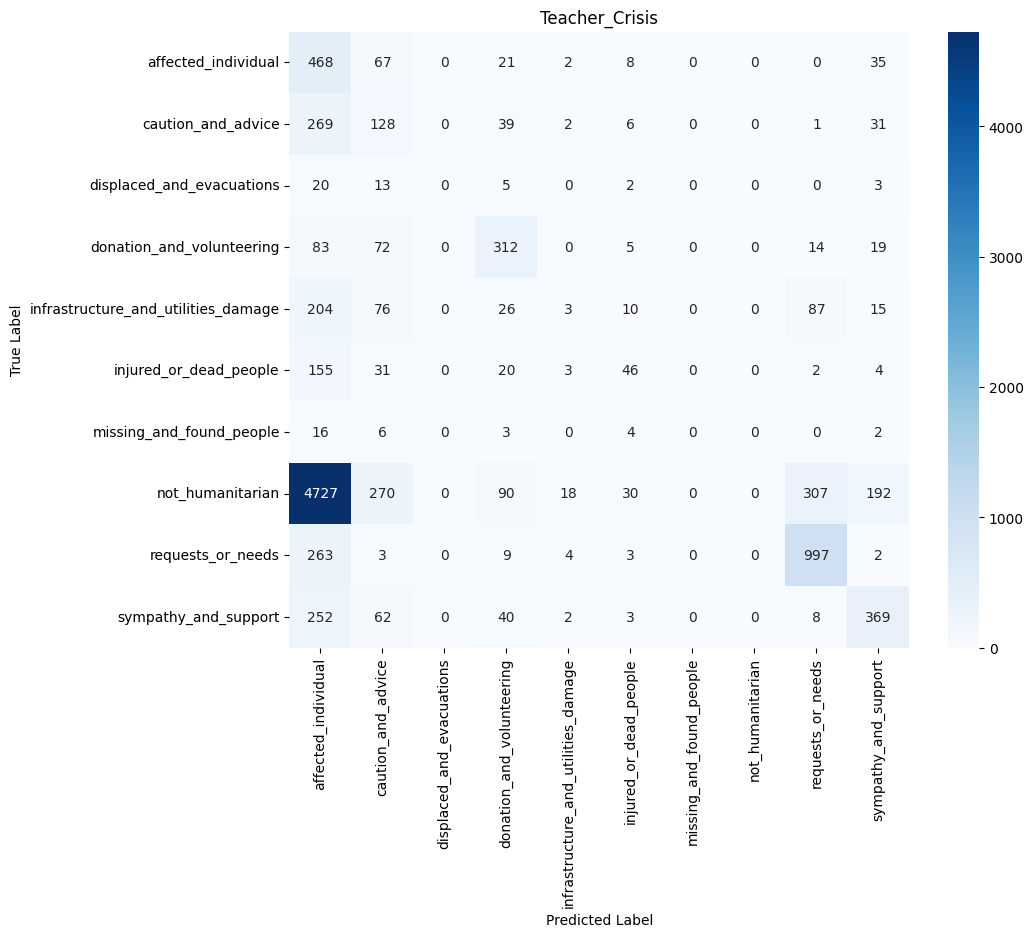

In [18]:

# ------------------ Step 1: Train Teacher Model ------------------
model_teacher = CrisisClassifier(input_size=tokenizer.vocab_size).to(device)
optimizer = torch.optim.AdamW(model_teacher.parameters(), lr=2e-5)
criterion_informativeness = nn.CrossEntropyLoss()

criterion_crisis = FocalLoss(weight=humanitarian_class_weights, device=device, gamma=2.0)
epochs = 10
print("\n🛠️ Training Teacher Model...")

for epoch in range(epochs):
  train_loss = train(
        model_teacher, train_loader, optimizer,
        criterion_informativeness, criterion_crisis,
        device=device,
        teacher_logits=None,
        alpha_train=0.01, alpha_dist=0.8,
        temperature=2.0,
        current_epoch=epoch,
        warmup_epochs=3
    )

# Evaluate teacher
info_true, info_preds, crisis_true, crisis_preds = eval_model(model_teacher, val_loader, device)

print("\n📜 Classification Report (Teacher)")
# Now print the report
print(classification_report(info_true, info_preds, target_names=[id2info[i] for i in sorted(id2info)]))
# Find all unique labels in crisis_true and crisis_preds
present_labels = sorted(set(np.unique(crisis_true)).union(np.unique(crisis_preds)))
print(classification_report( crisis_true, crisis_preds, labels=present_labels, target_names=[id2hum[i] for i in present_labels], zero_division=0 ))

# Plot the Confusion Matrix
plot_cm(info_true, info_preds, [id2info[i] for i in sorted(id2info)], "Teacher_Informativeness")
plot_cm(crisis_true, crisis_preds, [id2hum[i] for i in sorted(id2hum)], "Teacher_Crisis")

# Save teacher logits
teacher_logits = []
with torch.no_grad():
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        info_logits, crisis_logits = model_teacher(input_ids)
        teacher_logits.append((info_logits.detach(), crisis_logits.detach()))



🛠️ Training Student Model (Self-Distillation)...


Epoch 0 | Batch 546 | Total: 1.2334 | Info: 0.5354 | Crisis: 1.2404:   0%|          | 0/547 [00:17<?, ?it/s]
Epoch 0 | Batch 546 | Total: 1.0304 | Info: 0.6123 | Crisis: 1.0346:   0%|          | 0/547 [00:17<?, ?it/s]
Epoch 0 | Batch 546 | Total: 0.8556 | Info: 0.6994 | Crisis: 0.8572:   0%|          | 0/547 [00:17<?, ?it/s]
Epoch 0 | Batch 546 | Total: 1.3304 | Info: 0.6080 | Crisis: 1.3377:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 0 | Batch 546 | Total: 0.6554 | Info: 0.5048 | Crisis: 0.6569:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 0 | Batch 546 | Total: 0.6329 | Info: 0.5897 | Crisis: 0.6333:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 0 | Batch 546 | Total: 0.6987 | Info: 0.6937 | Crisis: 0.6988:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 0 | Batch 546 | Total: 0.6944 | Info: 0.5128 | Crisis: 0.6962:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 0 | Batch 546 | Total: 0.6905 | Info: 0.4980 | Crisis: 0.6925:   0%|          | 0/547 [00:16<?, ?it/s]
Epoch 0 | Batch 546


📜 Classification Report (Student)
                 precision    recall  f1-score   support

not_informative       0.77      0.77      0.77      5634
    informative       0.71      0.71      0.71      4355

       accuracy                           0.74      9989
      macro avg       0.74      0.74      0.74      9989
   weighted avg       0.74      0.74      0.74      9989

                                     precision    recall  f1-score   support

                affected_individual       0.07      0.77      0.12       601
                 caution_and_advice       0.16      0.34      0.22       476
          displaced_and_evacuations       0.00      0.00      0.00        43
          donation_and_volunteering       0.32      0.43      0.37       505
infrastructure_and_utilities_damage       0.24      0.01      0.03       421
             injured_or_dead_people       0.29      0.06      0.10       261
           missing_and_found_people       0.00      0.00      0.00        31
   

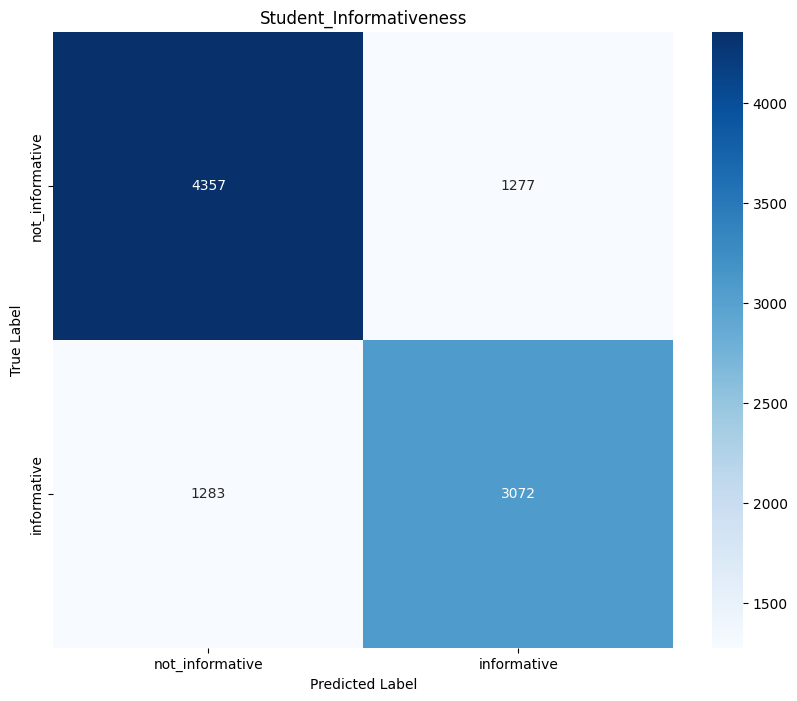

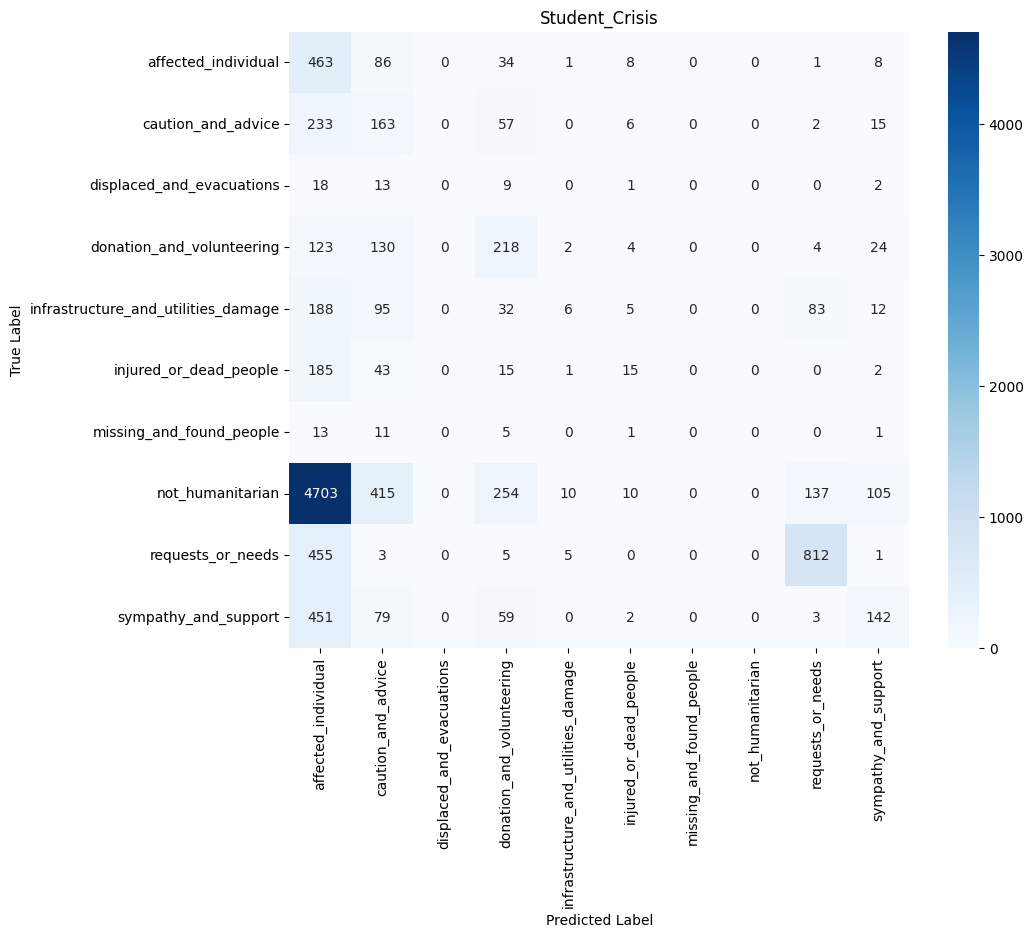

In [20]:
# ------------------ Step 2: Train Student Model with Self-Distillation ------------------
model_student = CrisisClassifier(input_size=tokenizer.vocab_size).to(device)
optimizer = torch.optim.AdamW(model_student.parameters(), lr=2e-5)

print("\n🛠️ Training Student Model (Self-Distillation)...")
for epoch in range(epochs):
    train_loss = train(model_student, train_loader, optimizer, criterion_informativeness, criterion_crisis, device, teacher_logits, alpha_dist = 0.95)


# Evaluate student
info_true, info_preds, crisis_true, crisis_preds = eval_model(model_student, val_loader, device)

print("\n📜 Classification Report (Student)")
print(classification_report(info_true, info_preds, target_names=[id2info[i] for i in sorted(id2info)]))

# Find all unique labels in crisis_true and crisis_preds
present_labels = sorted(set(np.unique(crisis_true)).union(np.unique(crisis_preds)))
print(classification_report( crisis_true, crisis_preds, labels=present_labels, target_names=[id2hum[i] for i in present_labels], zero_division=0 ))

plot_cm(info_true, info_preds, [id2info[i] for i in sorted(id2info)], "Student_Informativeness")
plot_cm(crisis_true, crisis_preds, [id2hum[i] for i in sorted(id2hum)], "Student_Crisis")
